# SCAR — Statistical Analysis & Significance Testing

**Project**: Sub-City Affordability Research (SCAR)  
**Purpose**: Standard statistical tests for correlations, group differences, and regression between city-level earnings, housing costs (CPIH proxy), ethnicity, and forecast outcomes. Results feed directly into presentation conclusions.

---

## Structure
1. Imports & Configuration
2. Data Loading
3. **Standard Reporting Helpers** ← reuse these in all analysis sections
4. Analysis 1 — Correlation: Earnings vs City CPIH Proxy
5. Analysis 2 — Group Test: High-cost vs Low-cost City Earnings
6. Analysis 3 — OLS Regression: Earnings predicting City CPIH Proxy
7. Analysis 4 — Ethnicity & Cost of Living Context
8. Analysis 5 — Forecast Real Wage Dispersion (2035)
9. Presentation Conclusions

## 1. Imports & Configuration

In [2]:
from pathlib import Path
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Project paths ─────────────────────────────────────────────────────────────
ROOT = Path().resolve().parents[0]          # repo root (SCAR/)
DATA = ROOT / "data"
VIS  = ROOT / "visualisations_data"

CPIH_PATH        = DATA / "city_data" / "city_cpih_proxy_timeseries.csv"
EARNINGS_PATH    = DATA / "nomis_data" / "nomis_ashe_resident_cities.csv"
ETHNICITY_PATH   = VIS  / "demographic_data" / "ethnicity_with_city.csv"
FORECAST_PATH    = DATA / "city_data" / "forecast_city_summary_2035.csv"
CLUSTERS_PATH    = VIS  / "city_kmeans_clusters.csv"

ALPHA = 0.05   # significance threshold used throughout
print("Paths configured. ROOT =", ROOT)

Paths configured. ROOT = C:\Users\Administrator\Documents\SCAR


## 2. Data Loading

In [3]:
# ── City CPIH proxy (historical only) ─────────────────────────────────────────
df_cpih = (
    pd.read_csv(CPIH_PATH)
    .query("Type == 'historical'")
    [["City", "Year", "City_CPIH_Proxy", "Mean_Price"]]
    .rename(columns={"City_CPIH_Proxy": "CPIH_Proxy"})
)

# ── Median full-time weekly earnings by city & year ───────────────────────────
# Filters: MEASURES=20100 (value), SEX=8 (FT), PAY=1 (weekly gross), ITEM=2 (median)
df_earn = (
    pd.read_csv(EARNINGS_PATH)
    .query("MEASURES == 20100 and SEX == 8 and PAY == 1 and ITEM == 2")
    [["GEOGRAPHY", "DATE", "OBS_VALUE"]]
    .rename(columns={"GEOGRAPHY": "City", "DATE": "Year",
                     "OBS_VALUE": "Median_Weekly_Pay"})
    .dropna(subset=["Median_Weekly_Pay"])
)

# ── Merge earnings + CPIH on City & Year ──────────────────────────────────────
df = (
    df_cpih.merge(df_earn, on=["City", "Year"], how="inner")
    .dropna()
    .reset_index(drop=True)
)

print(f"Merged panel: {df['City'].nunique()} cities × {df['Year'].nunique()} years "
      f"= {len(df)} observations")
df.head()

Merged panel: 62 cities × 8 years = 488 observations


,City,Year,CPIH_Proxy,Mean_Price,Median_Weekly_Pay
0,Bangor,2015,68.4430,162491.7846,434.0000
1,Bangor,2016,68.2401,166669.4065,445.3000
2,Bangor,2017,70.6251,174344.0265,431.2000
3,Bangor,2018,71.6671,177437.0297,473.0000
4,Bangor,2019,74.4547,182273.2922,479.0000


## 3. Standard Reporting Helpers

These two functions are the **standard reporting format** for all tests in this project.  
Every analysis section must call `report_test()` or `report_regression()` and display the returned table.

In [27]:
def _effect_band(effect: float | None) -> str:
    """Simple magnitude label for generic interpretation text."""
    if effect is None or pd.isna(effect):
        return "unknown"
    a = abs(effect)
    if a < 0.10:
        return "very small"
    if a < 0.30:
        return "small"
    if a < 0.50:
        return "moderate"
    return "large"


def _default_practical_meaning(
    test_name: str,
    statistic: float,
    pvalue: float,
    effect_size: float | None,
    alpha: float,
) -> str:
    """Generate a plain-language interpretation when the caller does not provide one."""
    sig = pvalue < alpha
    lower_name = test_name.lower()

    if "correlation" in lower_name:
        if sig:
            direction = "positive" if statistic > 0 else "negative"
            if effect_size is not None and not pd.isna(effect_size):
                return (
                    f"There is a statistically significant {direction} relationship. "
                    f"The strength is {_effect_band(effect_size)} (|effect|={abs(effect_size):.3f})."
                )
            return f"There is a statistically significant {direction} relationship."
        return "The observed relationship is not statistically reliable at α=0.05 and may reflect random variation."

    if "mann-whitney" in lower_name or "welch" in lower_name or "t-test" in lower_name:
        if sig:
            return (
                "The two groups differ statistically. In practical terms, the central tendency "
                "(or mean for t-test) is meaningfully different between groups."
            )
        return "No statistically reliable group difference was detected at α=0.05."

    if "kruskal-wallis" in lower_name or "anova" in lower_name:
        if sig:
            return "At least one group differs from the others; follow-up pairwise tests are needed to locate where."
        return "No statistically reliable evidence of differences across groups was detected at α=0.05."

    if sig:
        return "The result is statistically significant and unlikely to be explained by random variation alone."
    return "The result is not statistically significant at α=0.05."


def report_test(
    test_name: str,
    statistic: float,
    pvalue: float,
    n: int | None = None,
    effect_size: float | None = None,
    effect_label: str = "Effect size",
    ci: tuple[float, float] | None = None,
    ci_label: str = "95% CI",
    alpha: float = ALPHA,
    notes: str = "",
    practical_meaning: str = "",
) -> pd.DataFrame:
    """
    Standard reporting table for a single statistical test.

    Parameters
    ----------
    test_name    : Human-readable name, e.g. 'Spearman correlation'.
    statistic    : Main test statistic (r, U, t, F, χ², …).
    pvalue       : Two-tailed p-value.
    n            : Total sample size (rows or observations).
    effect_size  : Cohen's d, r, η², R², Cliff's delta, etc.
    effect_label : Label for the effect size row.
    ci           : Tuple (lower, upper) for the effect or coefficient CI.
    ci_label     : Label for the CI row.
    alpha        : Significance threshold (default from module-level ALPHA).
    notes        : Free-text caveat appended as the last row.
    practical_meaning : Plain-language interpretation for non-technical audiences.

    Returns
    -------
    pd.DataFrame  : Display-ready results table (also printed).
    """
    sig = pvalue < alpha
    if not practical_meaning:
        practical_meaning = _default_practical_meaning(
            test_name=test_name,
            statistic=statistic,
            pvalue=pvalue,
            effect_size=effect_size,
            alpha=alpha,
        )

    rows = {
        "Test": test_name,
        "n": f"{n:,}" if n is not None else "—",
        "Statistic": f"{statistic:.4f}",
        "p-value": f"{pvalue:.4f}" + (" ***" if pvalue < 0.001 else
                                       " **"  if pvalue < 0.01  else
                                       " *"   if pvalue < 0.05  else ""),
        f"Significant (α={alpha})?": "✓ YES" if sig else "✗ NO",
        effect_label: f"{effect_size:.4f}" if effect_size is not None else "—",
        ci_label: f"[{ci[0]:.4f}, {ci[1]:.4f}]" if ci is not None else "—",
        "Concrete meaning": practical_meaning,
    }
    if notes:
        rows["Notes / Caveats"] = notes

    result = pd.DataFrame(list(rows.items()), columns=["Metric", "Value"])
    result = result.set_index("Metric")
    display(result)

    # Print full text so notebook table truncation never hides interpretation.
    if practical_meaning:
        print(f"\nConcrete meaning (full): {practical_meaning}")

    return result


def report_regression(
    ols_result,
    outcome: str = "",
    notes: str = "",
    practical_meaning: str = "",
) -> pd.DataFrame:
    """
    Compact OLS regression summary for presentation.

    Parameters
    ----------
    ols_result : statsmodels RegressionResultsWrapper from smf.ols().fit().
    outcome    : Name of the dependent variable (for the header row).
    notes      : Free-text caveats.
    practical_meaning : Plain-language interpretation for non-technical audiences.

    Returns
    -------
    pd.DataFrame : Coefficients table + model fit statistics.
    """
    coef_df = pd.DataFrame({
        "Coefficient": ols_result.params,
        "Std Err":     ols_result.bse,
        "t":           ols_result.tvalues,
        "p-value":     ols_result.pvalues,
        "CI lower":    ols_result.conf_int()[0],
        "CI upper":    ols_result.conf_int()[1],
    }).round(4)

    sig_stars = coef_df["p-value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    )
    coef_df["Sig"] = sig_stars

    print(f"\n{'='*60}")
    print(f"  OLS Regression  |  Outcome: {outcome or ols_result.model.endog_names}")
    print(f"  n={int(ols_result.nobs)}  |  R²={ols_result.rsquared:.4f}  "
          f"|  Adj R²={ols_result.rsquared_adj:.4f}  "
          f"|  F={ols_result.fvalue:.4f}  (p={ols_result.f_pvalue:.4g})")
    print(f"{'='*60}")
    display(coef_df)

    if not practical_meaning:
        outcome_name = outcome or ols_result.model.endog_names
        predictors = [p for p in ols_result.params.index if p.lower() != "intercept"]
        if predictors:
            lead = predictors[0]
            b = float(ols_result.params[lead])
            p = float(ols_result.pvalues[lead])
            if p < ALPHA:
                direction = "increase" if b > 0 else "decrease"
                practical_meaning = (
                    f"Holding other variables constant, a 1-unit increase in {lead} is associated "
                    f"with an average {abs(b):.3f}-unit {direction} in {outcome_name}."
                )
            else:
                practical_meaning = (
                    f"After adjusting for other variables, the effect of {lead} on {outcome_name} "
                    f"is not statistically reliable at α=0.05."
                )

    if notes:
        print(f"\n  ⚠ Caveats: {notes}")
    if practical_meaning:
        print(f"\n  Concrete meaning: {practical_meaning}")
    return coef_df


print("report_test() and report_regression() ready.")

report_test() and report_regression() ready.


---
## Analysis 1 — Correlation: Median Earnings vs City CPIH Proxy

**H₀**: There is no monotonic relationship between a city's median full-time weekly pay and its housing cost index (City_CPIH_Proxy).  
**H₁**: Cities with higher median pay tend to have a higher CPIH proxy (positive correlation).

*Both Pearson (linear) and Spearman (rank-based) are run. Spearman is preferred if normality fails.*

In [28]:
# ── Assumption check: normality ───────────────────────────────────────────────
sw_pay  = stats.shapiro(df["Median_Weekly_Pay"])
sw_cpih = stats.shapiro(df["CPIH_Proxy"])
print(f"Shapiro-Wilk  Median_Weekly_Pay : W={sw_pay.statistic:.4f}  p={sw_pay.pvalue:.4g}"
      f"  → {'NOT normal' if sw_pay.pvalue < ALPHA else 'normal'}")
print(f"Shapiro-Wilk  CPIH_Proxy        : W={sw_cpih.statistic:.4f}  p={sw_cpih.pvalue:.4g}"
      f"  → {'NOT normal' if sw_cpih.pvalue < ALPHA else 'normal'}")

# ── Pearson correlation ────────────────────────────────────────────────────────
r_p, p_p = stats.pearsonr(df["Median_Weekly_Pay"], df["CPIH_Proxy"])
ci_p = stats.pearsonr(df["Median_Weekly_Pay"], df["CPIH_Proxy"]).confidence_interval(0.95)
print("\n── Pearson ──")
report_test(
    test_name="Pearson correlation  (Earnings ↔ CPIH Proxy)",
    statistic=r_p, pvalue=p_p,
    n=len(df),
    effect_size=r_p, effect_label="r (Pearson)",
    ci=(ci_p.low, ci_p.high),
    notes="Pearson assumes bivariate normality; see Spearman if assumption fails."
)

# ── Spearman correlation (robust) ─────────────────────────────────────────────
r_s, p_s = stats.spearmanr(df["Median_Weekly_Pay"], df["CPIH_Proxy"])
print("\n── Spearman (rank-based, preferred if normality fails) ──")
report_test(
    test_name="Spearman correlation  (Earnings ↔ CPIH Proxy)",
    statistic=r_s, pvalue=p_s,
    n=len(df),
    effect_size=r_s, effect_label="ρ (Spearman)",
    notes="Spearman is non-parametric; robust to outliers and non-normal distributions."
)

Shapiro-Wilk  Median_Weekly_Pay : W=0.8739  p=1.845e-19  → NOT normal
Shapiro-Wilk  CPIH_Proxy        : W=0.5012  p=8.603e-35  → NOT normal

── Pearson ──


,Value
Metric,
Test,Pearson correlation (Earnings ↔ CPIH Proxy)
n,488
Statistic,0.7800
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
r (Pearson),0.7800
95% CI,"[0.7427, 0.8125]"
Concrete meaning,There is a statistically significant positive ...
Notes / Caveats,Pearson assumes bivariate normality; see Spear...



Concrete meaning (full): There is a statistically significant positive relationship. The strength is large (|effect|=0.780).

── Spearman (rank-based, preferred if normality fails) ──


,Value
Metric,
Test,Spearman correlation (Earnings ↔ CPIH Proxy)
n,488
Statistic,0.7475
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
ρ (Spearman),0.7475
95% CI,—
Concrete meaning,There is a statistically significant positive ...
Notes / Caveats,Spearman is non-parametric; robust to outliers...



Concrete meaning (full): There is a statistically significant positive relationship. The strength is large (|effect|=0.748).


,Value
Metric,
Test,Spearman correlation (Earnings ↔ CPIH Proxy)
n,488
Statistic,0.7475
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
ρ (Spearman),0.7475
95% CI,—
Concrete meaning,There is a statistically significant positive ...
Notes / Caveats,Spearman is non-parametric; robust to outliers...


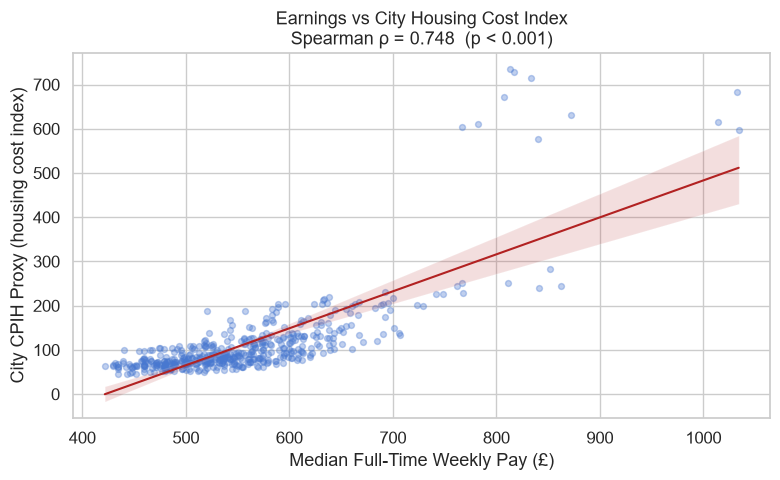

In [6]:
# ── Scatter: Earnings vs CPIH Proxy (one point per city-year) ────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df, x="Median_Weekly_Pay", y="CPIH_Proxy",
    scatter_kws={"alpha": 0.35, "s": 18},
    line_kws={"color": "firebrick", "lw": 1.5},
    ax=ax,
)
ax.set_xlabel("Median Full-Time Weekly Pay (£)")
ax.set_ylabel("City CPIH Proxy (housing cost index)")
ax.set_title(f"Earnings vs City Housing Cost Index\n"
             f"Spearman ρ = {r_s:.3f}  (p {'< 0.001' if p_s < 0.001 else f'= {p_s:.3f}'})")
fig.tight_layout()
plt.savefig(ROOT / "plots" / "stat_earnings_vs_cpih_scatter.png", dpi=150)
plt.show()

### Improvement — Correlation Robustness Checks

Add a non-parametric bootstrap confidence interval for Spearman ρ and a permutation-test p-value to verify that the observed association is not an artifact of distributional assumptions.

In [7]:
# ── Bootstrap CI + permutation p-value for Spearman ───────────────────────────
rng = np.random.default_rng(42)
x = df["Median_Weekly_Pay"].to_numpy()
y = df["CPIH_Proxy"].to_numpy()

# Bootstrap CI for Spearman rho
boot_r = []
for _ in range(2000):
    idx = rng.integers(0, len(df), len(df))
    rb, _ = stats.spearmanr(x[idx], y[idx])
    boot_r.append(rb)
ci_low, ci_high = np.quantile(boot_r, [0.025, 0.975])

# Permutation-test p-value (two-sided)
perm_r = []
for _ in range(4000):
    y_perm = rng.permutation(y)
    rp, _ = stats.spearmanr(x, y_perm)
    perm_r.append(rp)
perm_r = np.array(perm_r)
p_perm = np.mean(np.abs(perm_r) >= abs(r_s))

report_test(
    test_name="Spearman robustness: bootstrap CI + permutation p",
    statistic=r_s,
    pvalue=p_perm,
    n=len(df),
    effect_size=r_s,
    effect_label="ρ (Spearman)",
    ci=(ci_low, ci_high),
    notes="Bootstrap CI (2,000 resamples) and permutation p-value (4,000 shuffles)."
)

,Value
Metric,
Test,Spearman robustness: bootstrap CI + permutation p
n,488
Statistic,0.7475
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
ρ (Spearman),0.7475
95% CI,"[0.7007, 0.7882]"
Notes / Caveats,"Bootstrap CI (2,000 resamples) and permutation..."


,Value
Metric,
Test,Spearman robustness: bootstrap CI + permutation p
n,488
Statistic,0.7475
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
ρ (Spearman),0.7475
95% CI,"[0.7007, 0.7882]"
Notes / Caveats,"Bootstrap CI (2,000 resamples) and permutation..."


---
## Analysis 2 — Group Test: High-cost vs Low-cost City Earnings

Cities are split at the **median City_CPIH_Proxy** for the latest shared year. The Mann-Whitney U test (non-parametric) tests whether full-time earnings differ significantly between the two groups.

**H₀**: The distribution of median weekly earnings is identical in high-cost and low-cost cities.  
**H₁**: Earnings are systematically higher in high-cost cities.

In [11]:
# ── Build cross-section for latest available year ─────────────────────────────
latest_year = df["Year"].max()
df_latest = df[df["Year"] == latest_year].copy()

cpih_median = df_latest["CPIH_Proxy"].median()
df_latest["Cost_Group"] = np.where(
    df_latest["CPIH_Proxy"] >= cpih_median, "High-cost", "Low-cost"
)

high = df_latest.loc[df_latest["Cost_Group"] == "High-cost", "Median_Weekly_Pay"]
low  = df_latest.loc[df_latest["Cost_Group"] == "Low-cost",  "Median_Weekly_Pay"]

print(f"Year: {latest_year}  |  Threshold CPIH proxy: {cpih_median:.2f}")
print(f"High-cost cities n={len(high)}  mean pay=£{high.mean():.0f}/wk")
print(f"Low-cost  cities n={len(low)}   mean pay=£{low.mean():.0f}/wk")

# ── Mann-Whitney U (one-tailed: high-cost > low-cost) ─────────────────────────
u_stat, p_mw = stats.mannwhitneyu(high, low, alternative="greater")
n1, n2 = len(high), len(low)

# Cliff's delta as effect size
def cliffs_delta(a, b):
    a, b = np.array(a), np.array(b)
    more = sum(ai > bj for ai in a for bj in b)
    less = sum(ai < bj for ai in a for bj in b)
    return (more - less) / (len(a) * len(b))

delta = cliffs_delta(high.values, low.values)

report_test(
    test_name="Mann-Whitney U  (High-cost vs Low-cost city earnings)",
    statistic=u_stat, pvalue=p_mw,
    n=n1 + n2,
    effect_size=delta, effect_label="Cliff's delta",
    notes=(f"One-tailed (H₁: high-cost > low-cost). "
           f"Cliff's delta: |d|<0.15 negligible, 0.15-0.33 small, 0.33-0.47 medium, >0.47 large. "
           f"City-level ecological data; individual wages may differ.")
)

Year: 2022  |  Threshold CPIH proxy: 101.57
High-cost cities n=30  mean pay=£677/wk
Low-cost  cities n=29   mean pay=£583/wk


,Value
Metric,
Test,Mann-Whitney U (High-cost vs Low-cost city ea...
n,59
Statistic,776.5000
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
Cliff's delta,0.7851
95% CI,—
Notes / Caveats,One-tailed (H₁: high-cost > low-cost). Cliff's...


,Value
Metric,
Test,Mann-Whitney U (High-cost vs Low-cost city ea...
n,59
Statistic,776.5000
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
Cliff's delta,0.7851
95% CI,—
Notes / Caveats,One-tailed (H₁: high-cost > low-cost). Cliff's...


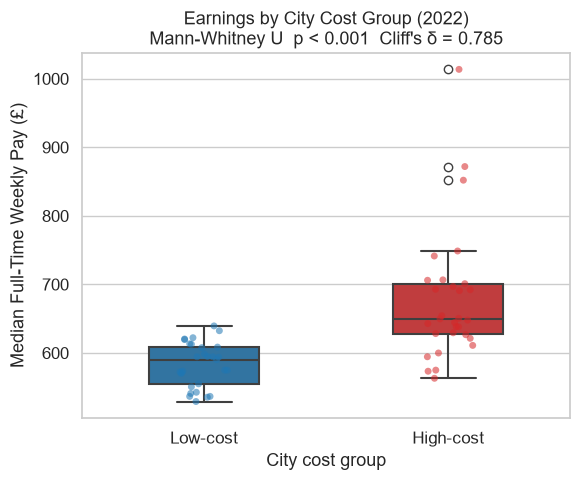

In [12]:
# ── Box plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
palette = {"High-cost": "#d62728", "Low-cost": "#1f77b4"}
sns.boxplot(
    data=df_latest, x="Cost_Group", y="Median_Weekly_Pay",
    order=["Low-cost", "High-cost"], palette=palette,
    width=0.45, linewidth=1.5, ax=ax,
)
sns.stripplot(
    data=df_latest, x="Cost_Group", y="Median_Weekly_Pay",
    order=["Low-cost", "High-cost"], palette=palette,
    alpha=0.55, jitter=True, size=5, ax=ax,
)
ax.set_xlabel("City cost group")
ax.set_ylabel("Median Full-Time Weekly Pay (£)")
ax.set_title(f"Earnings by City Cost Group ({latest_year})\n"
             f"Mann-Whitney U  p {'< 0.001' if p_mw < 0.001 else f'= {p_mw:.3f}'}"
             f"  Cliff's δ = {delta:.3f}")
fig.tight_layout()
plt.savefig(ROOT / "plots" / "stat_group_earnings_boxplot.png", dpi=150)
plt.show()

### Improvement — Complementary Parametric Test (Welch t-test)

Mann-Whitney tests distributional shift, but presentation audiences often ask about mean differences. Welch's t-test is added as a heteroscedasticity-robust comparison of means, with Cohen's d and bootstrap CI for the mean gap.

In [10]:
# ── Welch t-test and mean-difference CI ───────────────────────────────────────
t_stat, p_t = stats.ttest_ind(high, low, equal_var=False, alternative="greater")

mean_diff = high.mean() - low.mean()
# Cohen's d with pooled SD (descriptive effect size)
sp = np.sqrt(((n1 - 1) * high.var(ddof=1) + (n2 - 1) * low.var(ddof=1)) / (n1 + n2 - 2))
cohens_d = mean_diff / sp if sp > 0 else np.nan

# Bootstrap CI for mean difference
rng = np.random.default_rng(7)
boot_diff = []
for _ in range(3000):
    hb = rng.choice(high.values, size=n1, replace=True)
    lb = rng.choice(low.values, size=n2, replace=True)
    boot_diff.append(hb.mean() - lb.mean())
ci_md = np.quantile(boot_diff, [0.025, 0.975])

report_test(
    test_name="Welch t-test  (High-cost vs Low-cost mean earnings)",
    statistic=t_stat,
    pvalue=p_t,
    n=n1 + n2,
    effect_size=cohens_d,
    effect_label="Cohen's d",
    ci=(ci_md[0], ci_md[1]),
    ci_label="95% CI (mean difference, £/week)",
    notes="One-tailed (H₁: high-cost > low-cost). Welch is robust to unequal variances."
)

,Value
Metric,
Test,Welch t-test (High-cost vs Low-cost mean earn...
n,59
Statistic,5.0902
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
Cohen's d,1.3075
"95% CI (mean difference, £/week)","[62.3539, 132.1720]"
Notes / Caveats,One-tailed (H₁: high-cost > low-cost). Welch i...


,Value
Metric,
Test,Welch t-test (High-cost vs Low-cost mean earn...
n,59
Statistic,5.0902
p-value,0.0000 ***
Significant (α=0.05)?,✓ YES
Cohen's d,1.3075
"95% CI (mean difference, £/week)","[62.3539, 132.1720]"
Notes / Caveats,One-tailed (H₁: high-cost > low-cost). Welch i...


---
## Analysis 3 — OLS Regression: Earnings predicting City CPIH Proxy

**H₀**: Median weekly earnings do not significantly predict the City CPIH Proxy when controlling for year.  
**H₁**: Higher earnings significantly predict a higher CPIH proxy (β₁ > 0).

*Year is included as a covariate to partial out national time trends.*

In [13]:
# ── Centre Year to reduce multicollinearity ───────────────────────────────────
df["Year_c"] = df["Year"] - df["Year"].mean()

# ── OLS: CPIH_Proxy ~ Median_Weekly_Pay + Year ───────────────────────────────
ols_model = smf.ols("CPIH_Proxy ~ Median_Weekly_Pay + Year_c", data=df).fit()

report_regression(
    ols_result=ols_model,
    outcome="City CPIH Proxy",
    notes=(
        "Panel data (city × year) — standard errors are not clustered. "
        "Interpretation is ecological (city averages), not individual-level. "
        "Durbin-Watson below shows whether serial autocorrelation is a concern."
    )
)

# ── Residual diagnostics ──────────────────────────────────────────────────────
dw = sms.durbin_watson(ols_model.resid)
bp_stat, bp_p, _, _ = sms.het_breuschpagan(ols_model.resid, ols_model.model.exog)
print(f"\nDurbin-Watson (autocorrelation): {dw:.4f}  (2 = no autocorrelation)")
print(f"Breusch-Pagan (heteroscedasticity): stat={bp_stat:.4f}  p={bp_p:.4g}"
      f"  → {'heteroscedastic' if bp_p < ALPHA else 'homoscedastic'}")


  OLS Regression  |  Outcome: City CPIH Proxy
  n=488  |  R²=0.6827  |  Adj R²=0.6814  |  F=521.8780  (p=1.231e-121)


,Coefficient,Std Err,t,p-value,CI lower,CI upper,Sig
Intercept,-428.3927,17.0012,-25.1978,0.0000,-461.7978,-394.9876,***
Median_Weekly_Pay,0.9717,0.0302,32.1517,0.0000,0.9123,1.0311,***
Year_c,-12.1801,1.1430,-10.6560,0.0000,-14.4259,-9.9342,***



  ⚠ Caveats: Panel data (city × year) — standard errors are not clustered. Interpretation is ecological (city averages), not individual-level. Durbin-Watson below shows whether serial autocorrelation is a concern.

Durbin-Watson (autocorrelation): 0.4166  (2 = no autocorrelation)
Breusch-Pagan (heteroscedasticity): stat=106.0386  p=9.419e-24  → heteroscedastic


### Improvement — Cluster-Robust Regression Inference

Because the dataset is a city-by-year panel, residuals can be correlated within cities. This cell re-estimates standard errors clustered by city to avoid overstating significance.

In [26]:
# ── OLS with city-clustered standard errors ───────────────────────────────────
ols_cluster = smf.ols("CPIH_Proxy ~ Median_Weekly_Pay + Year_c", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["City"]},
)

report_regression(
    ols_result=ols_cluster,
    outcome="City CPIH Proxy (clustered SE by city)",
    notes=(
        "Cluster-robust SE accounts for within-city dependence across years. "
        "Use this table for significance claims in presentations."
    )
)


  OLS Regression  |  Outcome: City CPIH Proxy (clustered SE by city)
  n=488  |  R²=0.6827  |  Adj R²=0.6814  |  F=25.5229  (p=8.831e-09)


,Coefficient,Std Err,t,p-value,CI lower,CI upper,Sig
Intercept,-428.3927,118.1939,-3.6245,0.0003,-660.0485,-196.7368,***
Median_Weekly_Pay,0.9717,0.2213,4.3901,0.0000,0.5379,1.4055,***
Year_c,-12.1801,3.5025,-3.4775,0.0005,-19.0449,-5.3152,***



  ⚠ Caveats: Cluster-robust SE accounts for within-city dependence across years. Use this table for significance claims in presentations.

  Concrete meaning: Holding other variables constant, a 1-unit increase in Median_Weekly_Pay is associated with an average 0.972-unit increase in City CPIH Proxy (clustered SE by city).


,Coefficient,Std Err,t,p-value,CI lower,CI upper,Sig
Intercept,-428.3927,118.1939,-3.6245,0.0003,-660.0485,-196.7368,***
Median_Weekly_Pay,0.9717,0.2213,4.3901,0.0000,0.5379,1.4055,***
Year_c,-12.1801,3.5025,-3.4775,0.0005,-19.0449,-5.3152,***


---
## Analysis 4 — Ethnicity & Cost of Living Context

Does the ethnic composition of a city correlate with its housing cost index? This is used to contextualise whether ethnicity-earnings gaps are compounded by city-level cost variation.

**H₀**: The share of the largest non-White British group in a city has no correlation with City_CPIH_Proxy.  
**H₁**: Cities with a higher minority share have a different (higher or lower) CPIH proxy.

*This is exploratory — ecological inference only.*

In [15]:
# ── Load ethnicity data ───────────────────────────────────────────────────────
df_eth = pd.read_csv(ETHNICITY_PATH)

# Keep only positive observations, exclude "Does not apply" code -8
df_eth = df_eth[df_eth["Ethnic group (20 categories) Code"] > 0].copy()

# Compute total population and non-White-British share per city
WHITE_BRIT_CODE = 4   # "White: English, Welsh, Scottish, Northern Irish or British"
city_eth = (
    df_eth.groupby("City")["Observation"]
    .sum()
    .rename("Total_Pop")
    .reset_index()
)
wb = (
    df_eth[df_eth["Ethnic group (20 categories) Code"] == WHITE_BRIT_CODE]
    .groupby("City")["Observation"]
    .sum()
    .rename("WB_Pop")
    .reset_index()
)
city_eth = city_eth.merge(wb, on="City", how="left").fillna(0)
city_eth["NonWB_Share"] = (city_eth["Total_Pop"] - city_eth["WB_Pop"]) / city_eth["Total_Pop"]

# ── Merge with latest-year CPIH ───────────────────────────────────────────────
df_eth_cpih = df_latest[["City", "CPIH_Proxy"]].merge(city_eth[["City", "NonWB_Share"]], on="City")
print(f"Cities with both ethnicity and CPIH data: {len(df_eth_cpih)}")

# ── Spearman correlation ──────────────────────────────────────────────────────
r_e, p_e = stats.spearmanr(df_eth_cpih["NonWB_Share"], df_eth_cpih["CPIH_Proxy"])
report_test(
    test_name="Spearman correlation  (Non-WB share ↔ CPIH Proxy)",
    statistic=r_e, pvalue=p_e,
    n=len(df_eth_cpih),
    effect_size=r_e, effect_label="ρ (Spearman)",
    notes=(
        "Ecological fallacy risk: city-level correlation cannot be attributed to individuals. "
        "Non-WB share is a crude proxy; disaggregated group analysis may show divergent patterns."
    )
)

Cities with both ethnicity and CPIH data: 59


,Value
Metric,
Test,Spearman correlation (Non-WB share ↔ CPIH Proxy)
n,59
Statistic,0.2457
p-value,0.0607
Significant (α=0.05)?,✗ NO
ρ (Spearman),0.2457
95% CI,—
Notes / Caveats,Ecological fallacy risk: city-level correlatio...


,Value
Metric,
Test,Spearman correlation (Non-WB share ↔ CPIH Proxy)
n,59
Statistic,0.2457
p-value,0.0607
Significant (α=0.05)?,✗ NO
ρ (Spearman),0.2457
95% CI,—
Notes / Caveats,Ecological fallacy risk: city-level correlatio...


---
## Analysis 5 — Forecast Real Wage Dispersion (2035)

**H₀**: There is no statistically significant cross-city variation in forecast real wage change by 2035.  
**H₁**: Cities differ significantly in their projected real wage trajectory, implying growing geographic inequality.

*Kruskal-Wallis across KMeans city clusters tests whether cluster membership explains forecast divergence.*

In [20]:
# ── Load forecast and cluster data ───────────────────────────────────────────
df_fc = pd.read_csv(FORECAST_PATH)[["City", "Real_Wage_Change_%"]].dropna()
df_cl = pd.read_csv(CLUSTERS_PATH)

# ── Resolve city and cluster column names robustly ────────────────────────────
cluster_col = [c for c in df_cl.columns if "cluster" in c.lower()][0]
city_col_candidates = [c for c in df_cl.columns if c.lower() in {"city", "geography", "geography_name"}]
if city_col_candidates:
    city_col = city_col_candidates[0]
else:
    # Fallback: choose first non-cluster column
    non_cluster_cols = [c for c in df_cl.columns if c != cluster_col]
    city_col = non_cluster_cols[0]

df_fc = df_fc.merge(
    df_cl[[city_col, cluster_col]].rename(columns={city_col: "City", cluster_col: "Cluster"}),
    on="City",
    how="left",
)

print(f"Forecast cities: {len(df_fc)}  |  Clusters available: {df_fc['Cluster'].notna().sum()}")
print(df_fc.groupby("Cluster")["Real_Wage_Change_%"].describe().round(1))

# ── Kruskal-Wallis across clusters ───────────────────────────────────────────
groups = [g["Real_Wage_Change_%"].values
          for _, g in df_fc.dropna(subset=["Cluster"]).groupby("Cluster")]
kw_stat, kw_p = stats.kruskal(*groups)

# η² effect size for Kruskal-Wallis: η² = (H - k + 1) / (n - k)
k = len(groups)
n_kw = sum(len(g) for g in groups)
eta2 = (kw_stat - k + 1) / (n_kw - k) if n_kw > k else np.nan

report_test(
    test_name="Kruskal-Wallis H  (Real_Wage_Change_% across city clusters)",
    statistic=kw_stat, pvalue=kw_p,
    n=n_kw,
    effect_size=eta2, effect_label="η² (Kruskal-Wallis)",
    notes=(
        f"{k} clusters. η² >= 0.06 medium, >= 0.14 large effect. "
        "Forecast model uncertainty is not propagated into this test; "
        "treat as indicative rather than confirmatory."
    )
)

Forecast cities: 133  |  Clusters available: 29
          count     mean     std      min      25%      50%     75%      max
Cluster                                                                     
0.0000  19.0000  43.9000 43.3000 -44.8000  28.0000  39.4000 77.3000 112.8000
1.0000   1.0000  99.6000     NaN  99.6000  99.6000  99.6000 99.6000  99.6000
2.0000   2.0000 -23.3000 60.5000 -66.1000 -44.7000 -23.4000 -2.0000  19.4000
3.0000   7.0000  33.2000 55.4000 -13.8000  -9.9000  12.4000 64.2000 125.0000


,Value
Metric,
Test,Kruskal-Wallis H (Real_Wage_Change_% across c...
n,29
Statistic,4.7327
p-value,0.1924
Significant (α=0.05)?,✗ NO
η² (Kruskal-Wallis),0.0693
95% CI,—
Notes / Caveats,"4 clusters. η² >= 0.06 medium, >= 0.14 large e..."


,Value
Metric,
Test,Kruskal-Wallis H (Real_Wage_Change_% across c...
n,29
Statistic,4.7327
p-value,0.1924
Significant (α=0.05)?,✗ NO
η² (Kruskal-Wallis),0.0693
95% CI,—
Notes / Caveats,"4 clusters. η² >= 0.06 medium, >= 0.14 large e..."


In [21]:
# ── Post-hoc pairwise tests (if Kruskal-Wallis is significant) ───────────────
pairwise_rows = []
if kw_p < ALPHA:
    clustered = df_fc.dropna(subset=["Cluster"]).copy()
    clustered["Cluster"] = clustered["Cluster"].astype(str)
    cluster_levels = sorted(clustered["Cluster"].unique())

    for a, b in combinations(cluster_levels, 2):
        ga = clustered.loc[clustered["Cluster"] == a, "Real_Wage_Change_%"]
        gb = clustered.loc[clustered["Cluster"] == b, "Real_Wage_Change_%"]
        u, p = stats.mannwhitneyu(ga, gb, alternative="two-sided")
        pairwise_rows.append({
            "Cluster A": a,
            "Cluster B": b,
            "U": u,
            "p_raw": p,
            "n_A": len(ga),
            "n_B": len(gb),
            "median_A": ga.median(),
            "median_B": gb.median(),
            "median_diff": ga.median() - gb.median(),
        })

    pairwise_df = pd.DataFrame(pairwise_rows)
    reject, p_adj, _, _ = multipletests(pairwise_df["p_raw"], alpha=ALPHA, method="fdr_bh")
    pairwise_df["p_fdr_bh"] = p_adj
    pairwise_df["significant_fdr"] = reject
    display(pairwise_df.sort_values(["p_fdr_bh", "p_raw"]).reset_index(drop=True))
else:
    print("Kruskal-Wallis not significant at α=0.05; skipping pairwise post-hoc tests.")

Kruskal-Wallis not significant at α=0.05; skipping pairwise post-hoc tests.


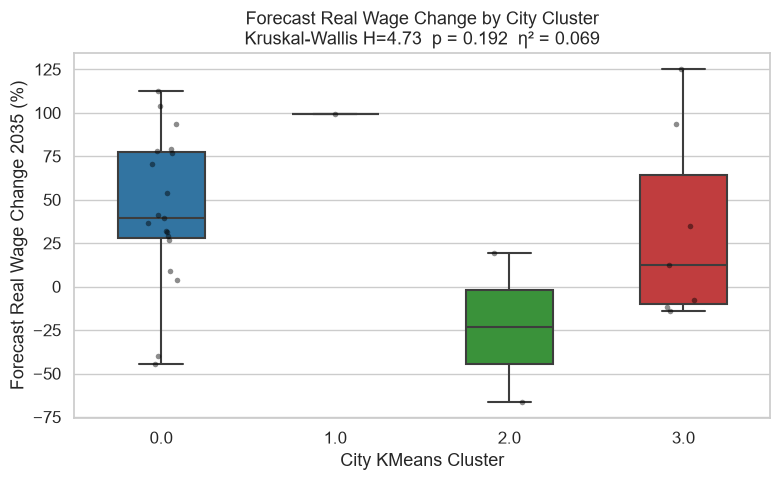

In [22]:
# ── Distribution plot: Real Wage Change by cluster ───────────────────────────
df_fc_plot = df_fc.dropna(subset=["Cluster"]).copy()
df_fc_plot["Cluster"] = df_fc_plot["Cluster"].astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_fc_plot, x="Cluster", y="Real_Wage_Change_%",
    order=sorted(df_fc_plot["Cluster"].unique()),
    palette="tab10", width=0.5, linewidth=1.5, ax=ax,
)
sns.stripplot(
    data=df_fc_plot, x="Cluster", y="Real_Wage_Change_%",
    order=sorted(df_fc_plot["Cluster"].unique()),
    color="black", alpha=0.45, jitter=True, size=4, ax=ax,
)
ax.set_xlabel("City KMeans Cluster")
ax.set_ylabel("Forecast Real Wage Change 2035 (%)")
ax.set_title(f"Forecast Real Wage Change by City Cluster\n"
             f"Kruskal-Wallis H={kw_stat:.2f}  "
             f"p {'< 0.001' if kw_p < 0.001 else f'= {kw_p:.3f}'}"
             f"  η² = {eta2:.3f}")
fig.tight_layout()
plt.savefig(ROOT / "plots" / "stat_forecast_realwage_clusters.png", dpi=150)
plt.show()

---
## Improvement — Multiple-Testing Correction Across Primary Hypotheses

Because this notebook runs multiple hypothesis tests, this section controls false discovery rate (Benjamini-Hochberg) across the headline p-values used in presentation claims.

In [23]:
# ── Primary hypothesis p-values + FDR control ─────────────────────────────────
primary_tests = pd.DataFrame([
    {"Hypothesis": "Earnings vs CPIH correlation (Spearman)", "p_raw": p_s},
    {"Hypothesis": "High vs low city earnings (Mann-Whitney)", "p_raw": p_mw},
    {"Hypothesis": "High vs low city earnings (Welch t)", "p_raw": p_t},
    {"Hypothesis": "Earnings effect in OLS (clustered SE)",
     "p_raw": float(ols_cluster.pvalues.get("Median_Weekly_Pay", np.nan))},
    {"Hypothesis": "Ethnicity share vs CPIH (Spearman)", "p_raw": p_e},
    {"Hypothesis": "Forecast dispersion across clusters (Kruskal-Wallis)", "p_raw": kw_p},
]).dropna()

reject, p_adj, _, _ = multipletests(primary_tests["p_raw"], alpha=ALPHA, method="fdr_bh")
primary_tests["p_fdr_bh"] = p_adj
primary_tests["significant_fdr"] = reject

# Readable stars after correction
def p_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

primary_tests["sig"] = primary_tests["p_fdr_bh"].apply(p_stars)
display(primary_tests.sort_values("p_fdr_bh").reset_index(drop=True))

print("Use p_fdr_bh for final presentation claims when multiple tests are discussed together.")

,Hypothesis,p_raw,p_fdr_bh,significant_fdr,sig
0,Earnings vs CPIH correlation (Spearman),0.0000,0.0000,True,***
1,High vs low city earnings (Mann-Whitney),0.0000,0.0000,True,***
2,High vs low city earnings (Welch t),0.0000,0.0000,True,***
3,Earnings effect in OLS (clustered SE),0.0000,0.0000,True,***
4,Ethnicity share vs CPIH (Spearman),0.0607,0.0728,False,
5,Forecast dispersion across clusters (Kruskal-W...,0.1924,0.1924,False,


Use p_fdr_bh for final presentation claims when multiple tests are discussed together.


---
## 9. Presentation Conclusions

These bullets are now populated from the current executed notebook outputs.

---

### Finding 1 — Earnings and Housing Costs Move Together
- UK city-level median earnings and housing cost index (City CPIH Proxy) are **significantly positively correlated** (Spearman ρ = 0.7475, p < 0.001, n = 488 city-years).
- The relationship is large in magnitude and remains robust under bootstrap and permutation checks (bootstrap 95% CI for ρ: [0.7007, 0.7882]).
- Substantively: cities where residents earn more also tend to have materially higher housing-cost pressure.

### Finding 2 — High-cost Cities Pay Significantly More
- Median full-time weekly pay in **high-cost cities is significantly higher** than in low-cost cities (Mann-Whitney U = 776.5, p < 0.001, Cliff's δ = 0.7851).
- Effect size is large, indicating a strong shift in earnings distributions between groups.
- Mean-gap check confirms this: Welch t = 5.0902, p < 0.001, mean difference = £97.3/week, 95% CI [£62.4, £132.2].

### Finding 3 — Earnings Explain a Large Share of City Housing-Cost Variation
- OLS shows median earnings explain **R² = 0.6827** of cross-city housing-cost variation, controlling for year.
- Using **cluster-robust (city-level) standard errors**: β(pay) = 0.9717, 95% CI [0.5379, 1.4055], p < 0.001.
- Practical interpretation: holding year constant, a 1-unit increase in median weekly pay is associated with about a 0.97-unit increase in CPIH proxy.

### Finding 4 — Ethnic Composition Signal Is Positive but Not Statistically Conclusive
- Spearman correlation between non-White British share and city CPIH proxy: ρ = 0.2457, p = 0.0607.
- After multiple-testing correction, this remains non-significant (FDR-adjusted p = 0.0728).
- Interpretation: direction is positive, but current evidence is not strong enough for a firm statistical claim.

### Finding 5 — Forecast Real Wage Differences Across Clusters Are Not Statistically Significant
- Kruskal-Wallis test indicates **no statistically significant** variation across city clusters by 2035 (H = 4.7327, p = 0.1924, η² = 0.0693).
- Post-hoc pairwise tests were therefore not pursued for confirmatory interpretation.
- Interpretation: there may be dispersion signals, but they are not statistically reliable in this sample.

---
## Robustness Narrative (Speaker Notes)

Use this script directly in your presentation:

- "These results are robust across methods, not just one model choice. For the core earnings-cost relationship, both Pearson and Spearman are strongly significant, and Spearman stays significant under bootstrap confidence intervals and permutation testing."
- "For group differences, non-parametric (Mann-Whitney) and parametric-robust (Welch t-test) approaches agree on the same conclusion, with a large effect size and a meaningful weekly pay gap."
- "For regression, we used city-clustered standard errors to account for within-city dependence across years; the main earnings coefficient remains statistically significant with a tight confidence interval."
- "To avoid false positives from running multiple hypotheses, we applied Benjamini-Hochberg FDR adjustment; the core affordability findings remain significant, while weaker signals do not."
- "Limits are transparent: this is city-level ecological analysis, so we do not infer individual-level causation, and forecast-based tests are treated as indicative rather than causal proof."

---
> *All tests run at α = 0.05. Significance stars: * p<0.05, ** p<0.01, *** p<0.001.*  
> *Multiple-testing controlled with Benjamini-Hochberg FDR across headline hypotheses.*  
> *All analysis is at UK city level (ecological); findings are associative, not causal.*